In [58]:
import sys
import os

sys.path.append("..")
import os

# create folders automatically
os.makedirs("../outputs/plots", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [60]:
from src.data_preprocessing import load_data, clean_data, encode_data

In [61]:
df = load_data("../data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [62]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

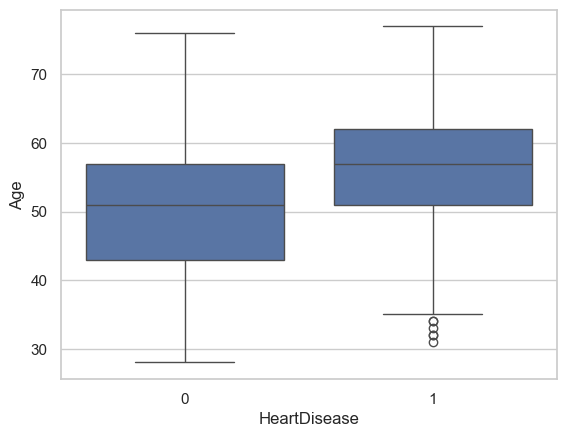

In [63]:
# Boxplot
sns.boxplot(data=df, y='Age', x='HeartDisease')
plt.show()

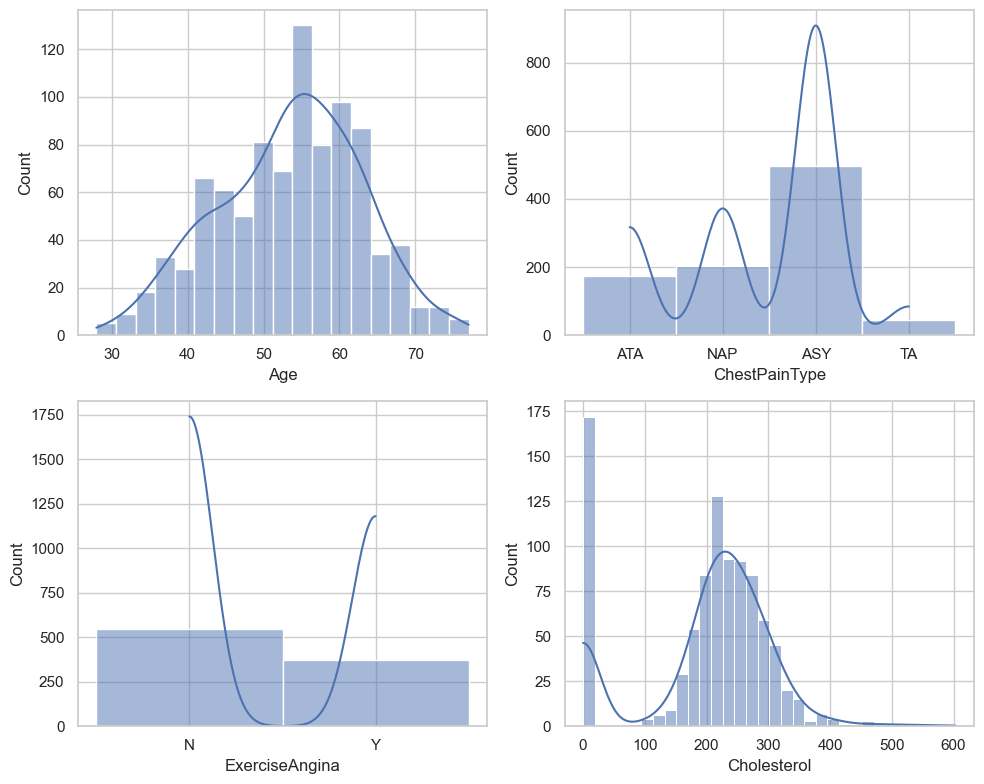

In [64]:
# Histograms
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
sns.histplot(df['Age'], kde=True)

plt.subplot(2,2,2)
sns.histplot(df['ChestPainType'], kde=True)

plt.subplot(2,2,3)
sns.histplot(df['ExerciseAngina'], kde=True)

plt.subplot(2,2,4)
sns.histplot(df['Cholesterol'], kde=True)

plt.tight_layout()
plt.show()

In [65]:
df = clean_data(df)

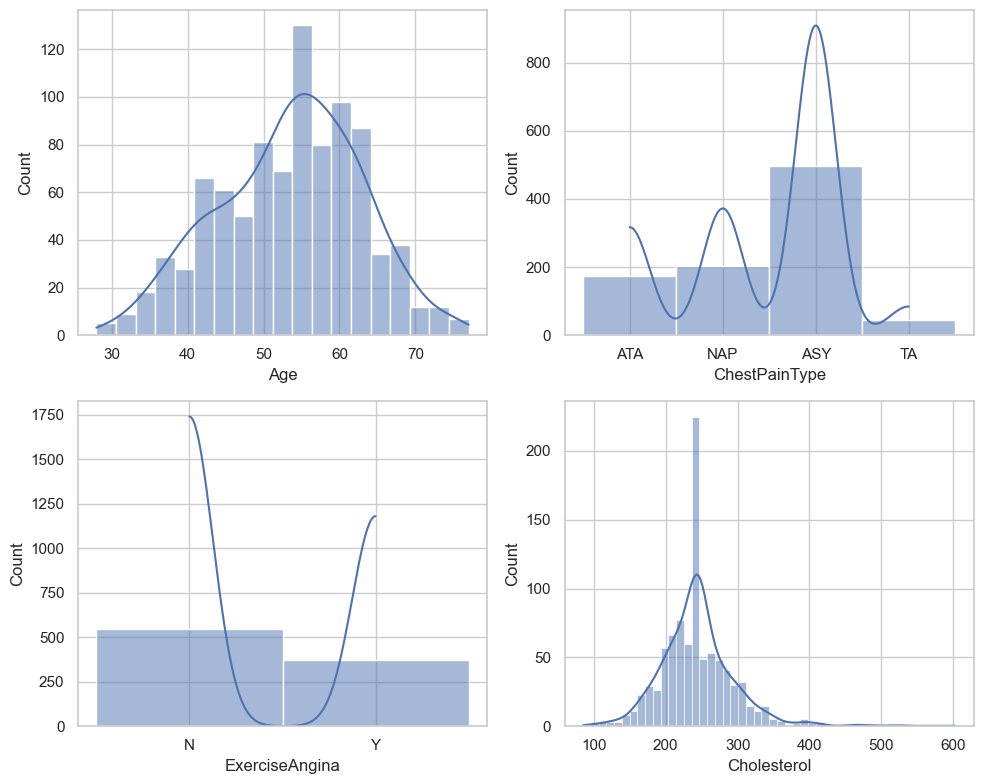

In [66]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
sns.histplot(df['Age'], kde=True)

plt.subplot(2,2,2)
sns.histplot(df['ChestPainType'], kde=True)

plt.subplot(2,2,3)
sns.histplot(df['ExerciseAngina'], kde=True)

plt.subplot(2,2,4)
sns.histplot(df['Cholesterol'], kde=True)

plt.tight_layout()
plt.savefig("../outputs/plots/histograms.png")
plt.show()


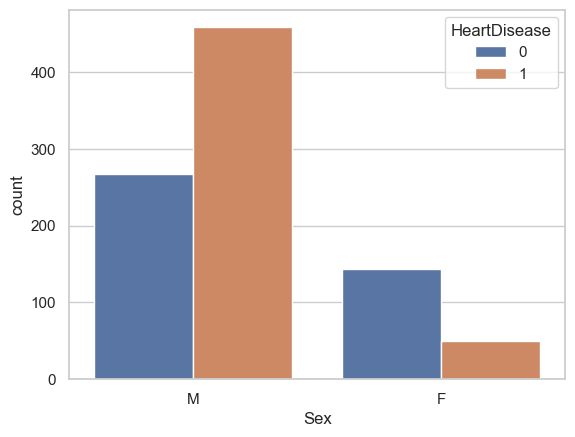

In [67]:
sns.countplot(x=df['Sex'], hue=df['HeartDisease'])
plt.show()

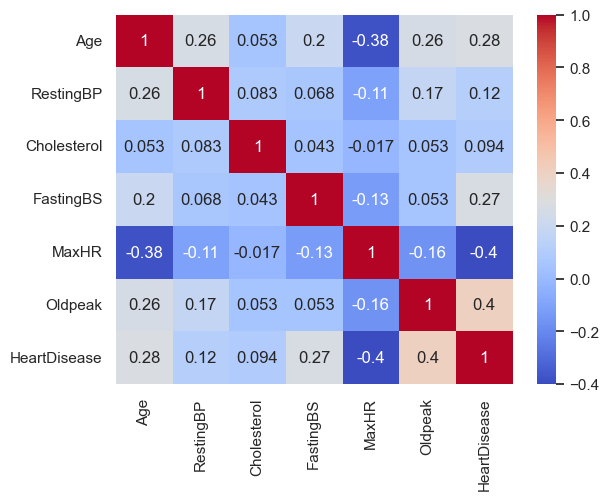

In [71]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.savefig("../outputs/plots/heatmap.png")
plt.show()

In [69]:
df_encoded = encode_data(df)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [70]:
df_encoded.to_csv("../data/processed_data.csv", index=False)